## Predikcija sekundarne strukture proteina primenom CNN+LSTM arhitekture i evolutivnih metoda optimizacije
-------
#### Sara Stojkov SV38/2023

Skup podataka koji će biti korišćen nalazi se na sledećem linku:
- CB513: https://www.kaggle.com/datasets/moklesur/cb513-dataset-for-protein-structure-prediction
- PSS (Protein Secondary Structure): https://www.kaggle.com/datasets/kirkdco/protein-secondary-structure-2022/data

CB513 dataset je u specifičnom .npy obliku - binarnom fajlu koji generiše numpy biblioteka i koji služi za čuvanje velikih array struktura podataka.
PSS je u csv formatu, pogodan za obradu.

Detaljniji opis strukture dataseta može se naći u ovom repozitorijumu: https://github.com/taneishi/CB513_dataset 


In [1]:
# ovo pokrenuti samo jednom, služi da prebaci dataset u format za python 3

import numpy as np

data = np.load('data/CB513.npy', allow_pickle=True, encoding='latin1')

np.save('data/CB513.npy', data)

print("File has been successfully converted to the correct format for python 3")
# ako ne izađe greška, znači da je sve u redu i da se može koristiti dataset u python 3

File has been successfully converted to the correct format for python 3


### 1. Učitavanje podataka / Eksplorativna analiza i vizuelizacija

In [2]:
from helpers.data_utils import load_csv_dataset

df = load_csv_dataset("data/2022-08-06-pdb-intersect-pisces_pc25_r2.5.csv")

print("Number of sequences:", len(df))
print(df.head(3))
print("\nExample sequence:", df.iloc[0]["seq"][:50])
print("Example sst3:     ", df.iloc[0]["sst3"][:50])
print("\nStatistics of sequence lengths:")
print(df["len"].describe())

Number of sequences: 9646
                                        seq  \
0  DTLDEAERQWKAEFHRWSSYMVHWKNQFDHYSKQDRCSDL   
1  KERQKVVEQMEHEMKEAAKALDFERAAELRDLLLELKAEG   
2  LAMPAAERLMQEKGVSPAEVQGTGLGGRILKEDVMRHLEE   

                                       sst3  len  
0  CCCCCHHHHHHHHHHHHHHHHHHHHHHCCCCCCCCCCCCC   40  
1  CHHHHHHHHHHHHHHHHHHCCCHHHHHHHHHHHHHHHCCC   40  
2  CCCHHHHHHHHHCCCCCCCCCCCCCCCCCCHHHHCCCCCC   40  

Example sequence: DTLDEAERQWKAEFHRWSSYMVHWKNQFDHYSKQDRCSDL
Example sst3:      CCCCCHHHHHHHHHHHHHHHHHHHHHHCCCCCCCCCCCCC

Statistics of sequence lengths:
count    9646.000000
mean      262.774103
std       161.918742
min        40.000000
25%       145.000000
50%       229.000000
75%       342.000000
max      2128.000000
Name: len, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from helpers.data_utils import dataframe_to_tensors

MAX_LEN = 400  

train_df, val_df = train_test_split(df, test_size=0.05, random_state=42)

X_train, y_train, mask_train = dataframe_to_tensors(train_df, MAX_LEN)
X_val, y_val, mask_val = dataframe_to_tensors(val_df, MAX_LEN)

print("Train:", X_train.shape, y_train.shape, mask_train.shape)
print("Val:  ", X_val.shape, y_val.shape, mask_val.shape)

# provera da maska ima smisla
print("Average percentage of 'real' positions (train):", mask_train.mean())

Train: (9163, 400, 21) (9163, 400) (9163, 400)
Val:   (483, 400, 21) (483, 400) (483, 400)
Average percentage of 'real' positions (train): 0.6007798


In [5]:
data = np.load("data/CB513.npy")
print("Shape:", data.shape)
print("Min/Max values:", data.min(), data.max())
print("Average values of the first position of the first protein:")
print(data[0, 0, :30].mean() if data.ndim == 3 else data[0, :30].mean())

Shape: (514, 39900)
Min/Max values: 0.0 1.0
Average values of the first position of the first protein:
0.06666666666666667


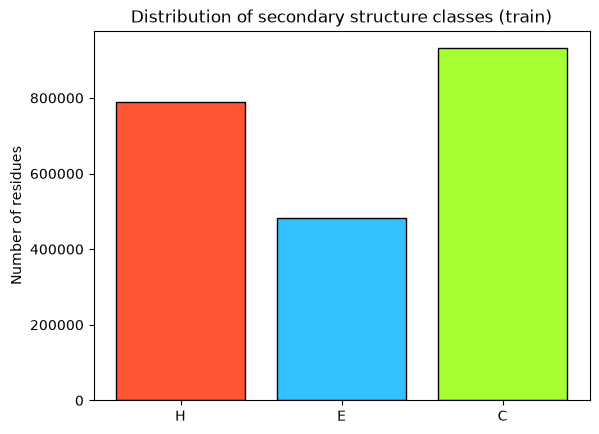

{'H': np.int64(788925), 'E': np.int64(481979), 'C': np.int64(931074)}


In [13]:
import matplotlib.pyplot as plt

all_labels = y_train[mask_train == 1]
unique, counts = np.unique(all_labels, return_counts=True)
labels_names = ["H", "E", "C"]

plt.bar([labels_names[i] for i in unique], counts, color=["#FF5733", "#33C1FF", "#A6FF33"], edgecolor="black")
plt.title("Distribution of secondary structure classes (train)")
plt.ylabel("Number of residues")
plt.show()

print(dict(zip([labels_names[i] for i in unique], counts)))

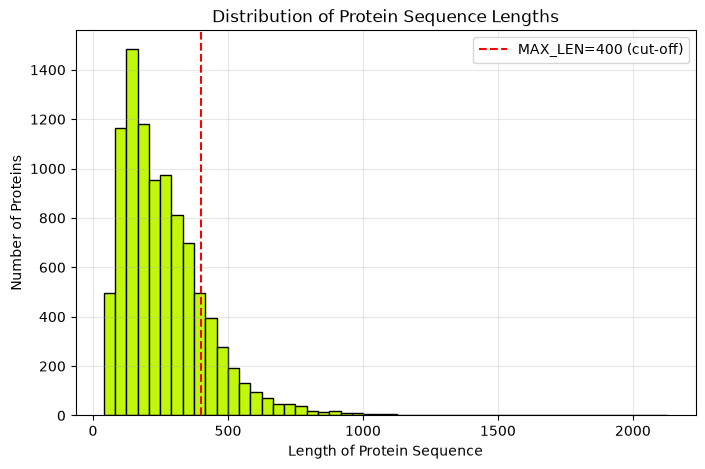

Percentage of proteins longer than 400: 16.1%


In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["len"], bins=50, edgecolor="black", color="#C1F80A")
plt.xlabel("Length of Protein Sequence")
plt.ylabel("Number of Proteins")
plt.title("Distribution of Protein Sequence Lengths")
plt.axvline(400, color="red", linestyle="--", label="MAX_LEN=400 (cut-off)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Percentage of proteins longer than 400: {(df['len'] > 400).mean()*100:.1f}%")

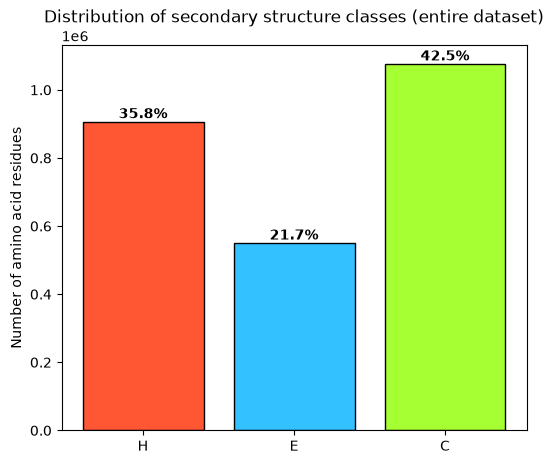

In [15]:
from collections import Counter

all_chars = Counter("".join(df["sst3"].tolist()))
labels_order = ["H", "E", "C"]
counts = [all_chars[l] for l in labels_order]
total = sum(counts)
percentages = [c/total*100 for c in counts]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels_order, counts, color=["#FF5733", "#33C1FF", "#A6FF33"], edgecolor="black")
for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{pct:.1f}%",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Number of amino acid residues")
ax.set_title("Distribution of secondary structure classes (entire dataset)")
plt.show()

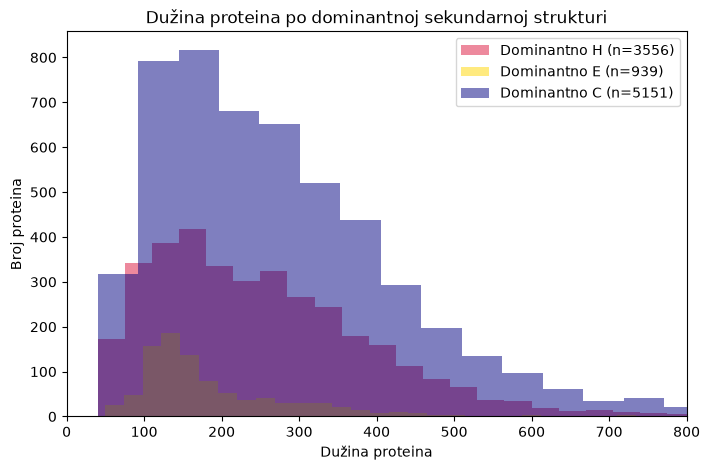

In [ ]:
import numpy as np

def dominant_class(sst3_string):
    c = Counter(sst3_string)
    return c.most_common(1)[0][0]

df["dominant_ss"] = df["sst3"].apply(dominant_class)

plt.figure(figsize=(8, 5))
for label, color in zip(["H", "E", "C"], ["#FF5733", "#33C1FF", "#A6FF33"]):
    subset = df[df["dominant_ss"] == label]["len"]
    plt.hist(subset, bins=40, alpha=0.5, label=f"Dominant {label} (n={len(subset)})", color=color)
plt.xlabel("Length of Protein Sequence")
plt.ylabel("Number of Proteins")
plt.title("Length of Proteins by Dominant Secondary Structure")
plt.legend()
plt.xlim(0, 800)
plt.show()

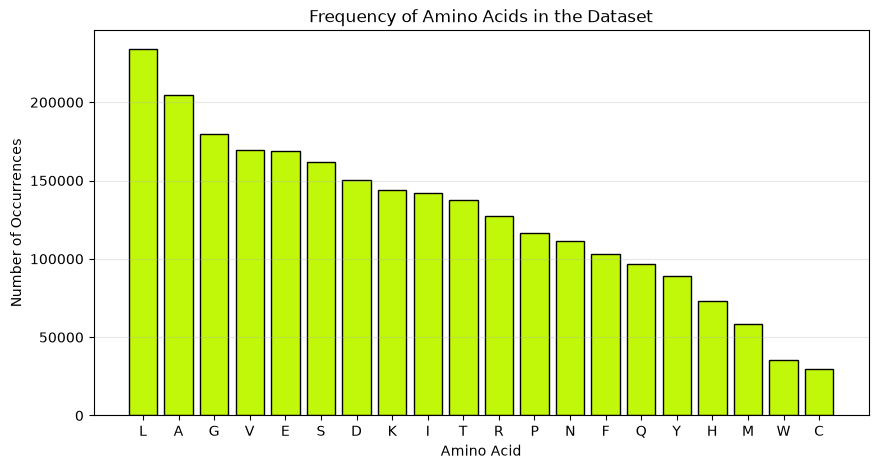

In [18]:
aa_counts = Counter("".join(df["seq"].str.replace("*", "", regex=False).tolist()))
aa_sorted = sorted(aa_counts.items(), key=lambda x: -x[1])
aas, counts = zip(*aa_sorted)

plt.figure(figsize=(10, 5))
plt.bar(aas, counts, color="#C1F80A", edgecolor="black")
plt.xlabel("Amino Acid")
plt.ylabel("Number of Occurrences")
plt.title("Frequency of Amino Acids in the Dataset")
plt.grid(axis="y", alpha=0.3)
plt.show()

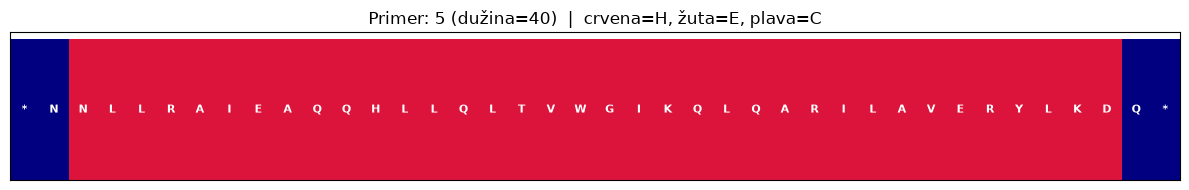

In [ ]:
# example visualization of a single protein sequence with its secondary structure

example = df.iloc[5]  
seq = example["seq"]
sst3 = example["sst3"]

color_map = {"H": "crimson", "E": "gold", "C": "navy"}
colors = [color_map[c] for c in sst3]

fig, ax = plt.subplots(figsize=(min(len(seq)*0.3, 20), 2))
ax.bar(range(len(seq)), [1]*len(seq), color=colors, width=1.0)
for i, aa in enumerate(seq):
    ax.text(i, 0.5, aa, ha="center", va="center", fontsize=8, color="white", fontweight="bold")
ax.set_xlim(-0.5, len(seq)-0.5)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title(f"Example: {example.name} (length={len(seq)})  |  red=H, yellow=E, blue=C")
plt.tight_layout()
plt.show()

### 2. Treniranje CNN+LSTM modela i evaluacija


In [ ]:
from helpers.model import CNNLSTMModel
import torch

m = CNNLSTMModel()
test_input = torch.randn(4, 400, 21)  # batch=4, seq_len=400, input_dim=21
out = m(test_input)
print(out.shape)  # expected output shape: (4, 400, 3)

torch.Size([4, 400, 3])


In [22]:
from helpers.train import train_model

test_hp = {"n_filters": 32, "kernel_size": 5, "lstm_units": 64,
           "dropout": 0.3, "lr": 0.001, "batch_size": 32}

acc = train_model(test_hp, X_train, y_train, mask_train,
                   X_val, y_val, mask_val, max_epochs=2)
print("Val Q3 accuracy after 2 epochs:", acc)

acc2 = train_model(test_hp, X_train, y_train, mask_train,
                   X_val, y_val, mask_val, max_epochs=3)

print("Val Q3 accuracy after 3 epochs:", acc2)

Val Q3 accuracy after 2 epochs: 0.6912885999946865
Val Q3 accuracy after 3 epochs: 0.692882634762356


Nakon svega 2 epohe, model dostiže Q3 tačnost od 69.1%, značajno iznad baseline-a od predviđanja isključivo dominantne klase (klase C tj. coil koja ima frekvenciju ~42%). Ovo potvrđuje da pipeline za trening ispravno funkcioniše.

Nakon 3 epohe, model dostiže Q3 tačnost od 69.3%, što je takođe dosta dobro. 

### 3. Metode optimizacije

In [ ]:
from helpers.optimizers.random_search import random_search

N_EVALS = 8  # same number for all algorithms for fair comparison

rs_config, rs_acc, rs_history = random_search(
    n_iter=N_EVALS,
    X_train=X_train, y_train=y_train, mask_train=mask_train,
    X_val=X_val, y_val=y_val, mask_val=mask_val,
    max_epochs=3
)
print("\nBest Random Search config:", rs_config)
print("Best accuracy:", rs_acc)

[RandomSearch 1/8] acc=0.7138 config={'n_filters': 120, 'kernel_size': np.int64(5), 'lstm_units': 253, 'dropout': 0.2356154421551128, 'lr': 0.007422510167415638, 'batch_size': np.int64(32)}
[RandomSearch 2/8] acc=0.7075 config={'n_filters': 120, 'kernel_size': np.int64(3), 'lstm_units': 96, 'dropout': 0.317532868333664, 'lr': 0.0018438799845989211, 'batch_size': np.int64(32)}


In [ ]:
from helpers.optimizers.genetic_algorithm import genetic_algorithm

ga_config, ga_acc, ga_history = genetic_algorithm(
    pop_size=4, n_generations=1,  # 4*2=8 evaluations in total, comparable to N_EVALS
    X_train=X_train, y_train=y_train, mask_train=mask_train,
    X_val=X_val, y_val=y_val, mask_val=mask_val,
    max_epochs=3
)
print("\nBest GA config:", ga_config)
print("Best accuracy:", ga_acc)

In [ ]:
from helpers.optimizers.pso import pso

pso_config, pso_acc, pso_history = pso(
    n_particles=4, n_iterations=2,  # 4*2=8 evaluacija
    X_train=X_train, y_train=y_train, mask_train=mask_train,
    X_val=X_val, y_val=y_val, mask_val=mask_val,
    max_epochs=3
)
print("\nBest PSO config:", pso_config)
print("Best accuracy:", pso_acc)

In [ ]:
from helpers.optimizers.bayesian_opt import bayesian_optimization

bayes_config, bayes_acc, bayes_history = bayesian_optimization(
    n_calls=8,
    X_train=X_train, y_train=y_train, mask_train=mask_train,
    X_val=X_val, y_val=y_val, mask_val=mask_val,
    max_epochs=3
)
print("\nBest Bayes config:", bayes_config)
print("Best accuracy:", bayes_acc)

In [ ]:
from helpers.visualize import plot_convergence

histories = {
    "Random Search": rs_history,
    "GA": ga_history,
    "PSO": pso_history,
    "Bayes": bayes_history,
}
plot_convergence(histories)

results_summary = {
    "Random Search": rs_acc, "GA": ga_acc, "PSO": pso_acc, "Bayes": bayes_acc
}
best_method = max(results_summary, key=results_summary.get)
print("Results:", results_summary)
print("Best method:", best_method)